# U02.E04 â€” Evidencias de VisiÃ³n Computacional

## Fashion-MNIST â€” Baseline Dense vs CNN

Notebook ejecutado para documentar la auditorÃ­a de datos, particiÃ³n reproducible,
mÃ©tricas, costos computacionales y errores del modelo CNN.

**Semilla:** 42  
**Dataset:** Fashion-MNIST  
**ParticiÃ³n:** 54,000 entrenamiento / 6,000 validaciÃ³n / 10,000 prueba


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

ROOT = Path.cwd().parent

print("Proyecto:", ROOT)
print("TensorFlow:", tf.__version__)
print("Dataset: Fashion-MNIST")
print("Semilla:", 42)


Proyecto: C:\Users\raine\Desktop\Ciencias de Datos II\INF8239_U02\INF8239_U02_CV_Proyecto_Base
TensorFlow: 2.21.0
Dataset: Fashion-MNIST
Semilla: 42


## 1. AuditorÃ­a de la particiÃ³n

El cÃ³digo de entrenamiento (`scripts/train_cv.py`) utiliza Fashion-MNIST y
mantiene el conjunto de prueba separado.

La particiÃ³n utilizada es:

- Entrenamiento: 54,000 imÃ¡genes
- ValidaciÃ³n: 6,000 imÃ¡genes
- Prueba: 10,000 imÃ¡genes
- Total: 70,000 imÃ¡genes
- Semilla declarada: 42

La normalizaciÃ³n se realiza mediante la funciÃ³n `normalize_images` antes
del entrenamiento.


In [2]:
metrics_path = ROOT / "reports" / "cv_metrics.json"

with metrics_path.open(encoding="utf-8") as f:
    metrics = json.load(f)

metrics_df = pd.DataFrame(metrics).T
metrics_df.index.name = "modelo"

metrics_df


,f1_macro,parameters,train_seconds,inference_ms_per_image
modelo,,,,
dense,0.863381,50890.0,8.007171,0.050095
cnn,0.789303,19466.0,114.243383,0.118091


## 2. ComparaciÃ³n de desempeÃ±o y costo

Los resultados siguientes corresponden a la ejecuciÃ³n real de
`scripts/train_cv.py --epochs 8`.

La mÃ©trica principal es **F1 Macro**.


In [3]:
display(
    metrics_df[
        ["f1_macro", "parameters", "train_seconds", "inference_ms_per_image"]
    ].sort_values("f1_macro", ascending=False)
)


,f1_macro,parameters,train_seconds,inference_ms_per_image
modelo,,,,
dense,0.863381,50890.0,8.007171,0.050095
cnn,0.789303,19466.0,114.243383,0.118091


In [4]:
dense_f1 = metrics["dense"]["f1_macro"]
cnn_f1 = metrics["cnn"]["f1_macro"]

f1_difference = dense_f1 - cnn_f1
train_ratio = metrics["cnn"]["train_seconds"] / metrics["dense"]["train_seconds"]
inference_ratio = (
    metrics["cnn"]["inference_ms_per_image"]
    / metrics["dense"]["inference_ms_per_image"]
)

print(f"Diferencia F1 Macro (Dense - CNN): {f1_difference:.6f}")
print(f"CNN / Dense â€” tiempo de entrenamiento: {train_ratio:.2f}x")
print(f"CNN / Dense â€” tiempo de inferencia: {inference_ratio:.2f}x")


Diferencia F1 Macro (Dense - CNN): 0.074079
CNN / Dense â€” tiempo de entrenamiento: 14.27x
CNN / Dense â€” tiempo de inferencia: 2.36x


## 3. Evidencia visual

Las siguientes figuras fueron generadas durante el entrenamiento real del
modelo CNN y forman parte de los artefactos del proyecto.


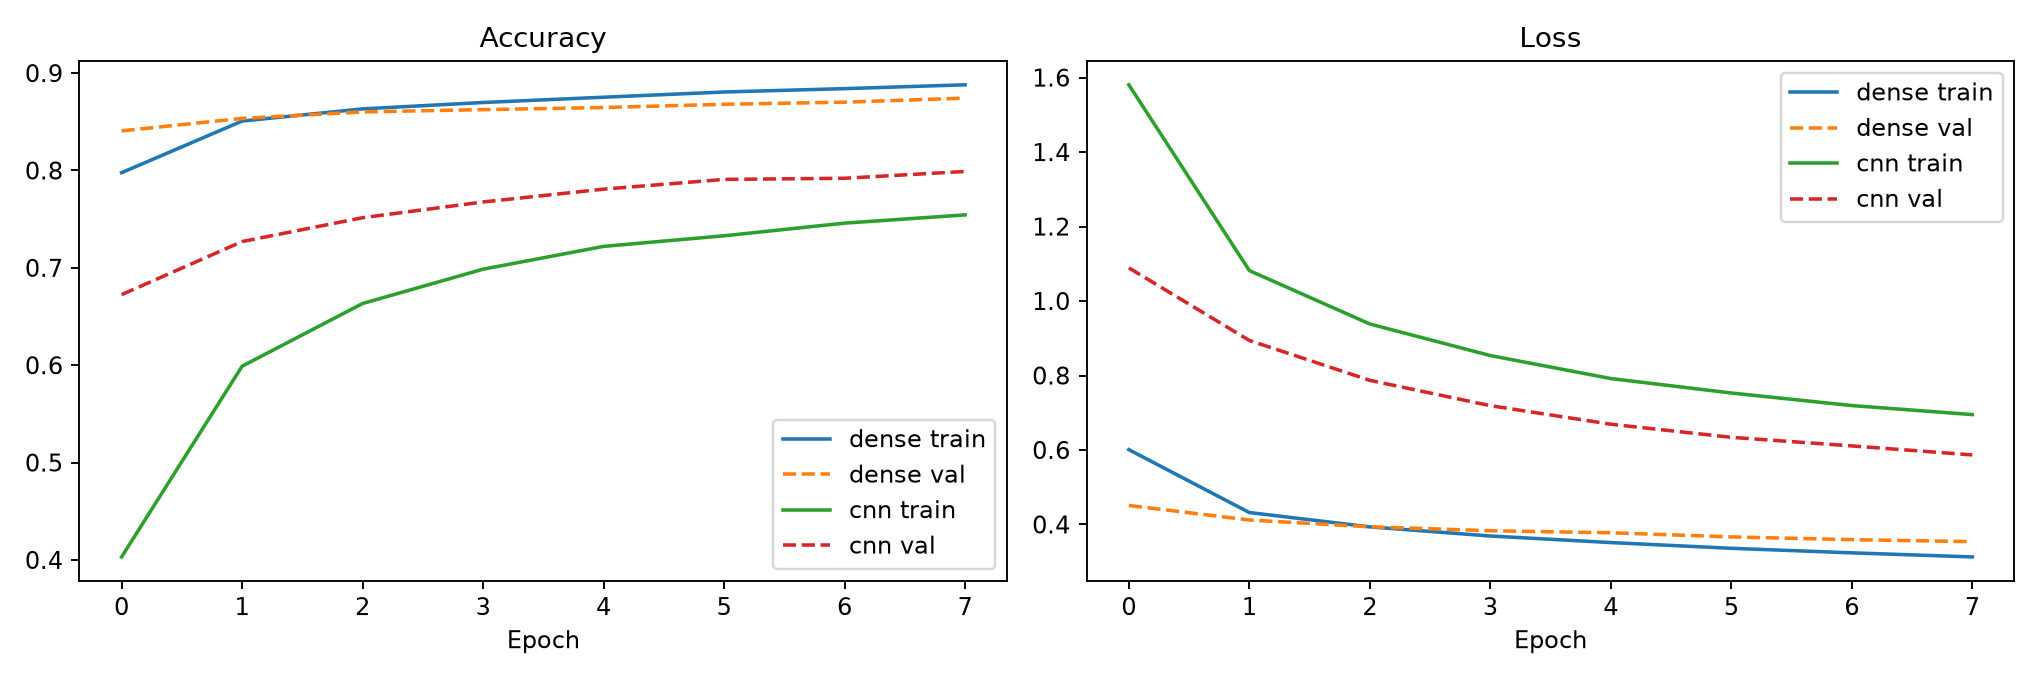

In [5]:
from IPython.display import Image, display

curves_path = ROOT / "reports" / "training_curves.png"
display(Image(filename=str(curves_path)))

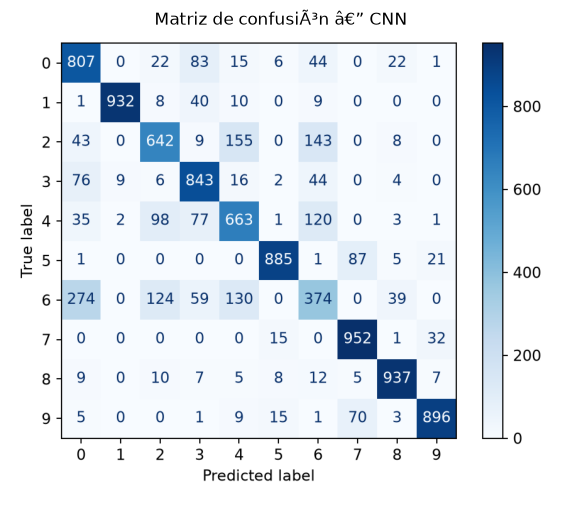

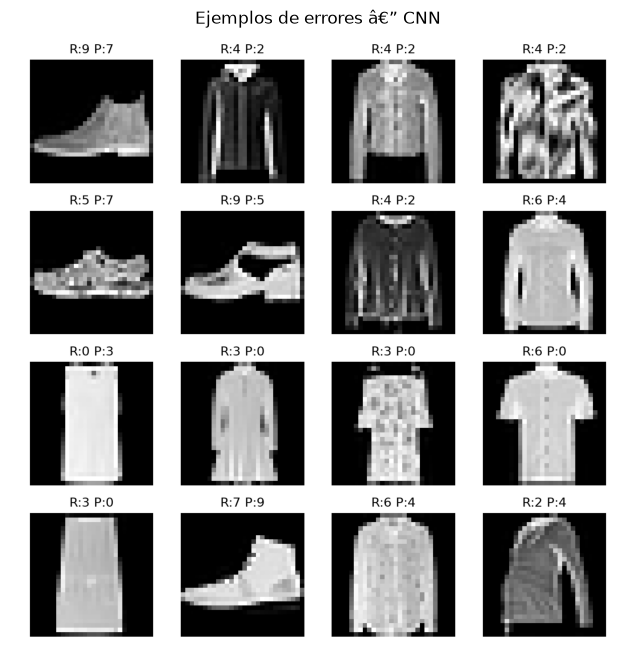

In [6]:
confusion_path = ROOT / "reports" / "confusion_cnn.png"
errors_path = ROOT / "reports" / "cnn_errors.png"

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(plt.imread(confusion_path))
ax.axis("off")
ax.set_title("Matriz de confusiÃ³n â€” CNN")
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(plt.imread(errors_path))
ax.axis("off")
ax.set_title("Ejemplos de errores â€” CNN")
plt.show()


## 4. InterpretaciÃ³n tÃ©cnica

En la ejecuciÃ³n registrada, el modelo Dense obtuvo un F1 Macro superior al
CNN. Por tanto, bajo las condiciones experimentales utilizadas, la CNN no
demostrÃ³ una ventaja predictiva que justificara su mayor costo computacional.

La CNN utilizÃ³ menos parÃ¡metros, pero presentÃ³ un tiempo de entrenamiento y
una latencia de inferencia mayores. Esto demuestra que la cantidad de
parÃ¡metros por sÃ­ sola no determina el costo total de ejecuciÃ³n.

La decisiÃ³n tÃ©cnica debe considerar simultÃ¡neamente desempeÃ±o, tiempo de
entrenamiento, inferencia, tamaÃ±o del modelo y facilidad de despliegue.


## 5. Reproducibilidad

Los principales artefactos utilizados para reproducir el experimento son:

- `scripts/train_cv.py`
- `scripts/check_runtime.py`
- `reports/cv_metrics.json`
- `reports/training_curves.png`
- `reports/confusion_cnn.png`
- `reports/cnn_errors.png`
- `models/best_cnn.keras`
- `requirements.txt`
- `README.md`
- `MODEL_CARD.md`

Las pruebas automatizadas fueron ejecutadas con:

`uv run --active pytest -q`

Resultado verificado: **2 passed, 1 skipped**.
